# 02-Regression


In [35]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 

In [36]:
url = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

In [37]:
df = pd.read_csv(url)

## preparing dataset

In [84]:
x_cols = ['engine_displacement','horsepower',
'vehicle_weight','model_year']
y_col = "fuel_efficiency_mpg"
all_present = set(x_cols).issubset(df.columns)
print(all_present)

True


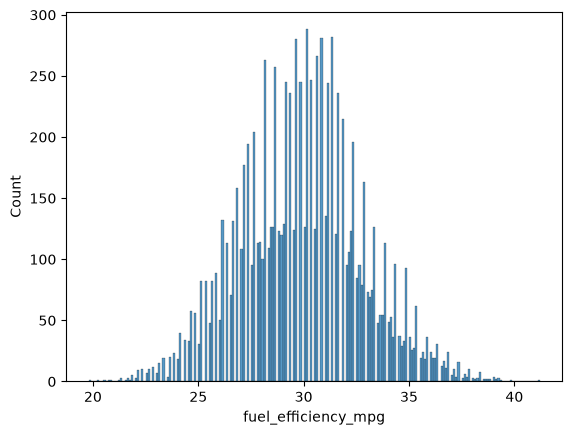

In [85]:


sns.histplot(data=df, x="fuel_efficiency_mpg", binwidth=0.1)
plt.show()

In [86]:
df.isnull().sum(axis=0)

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

horsepower has missing values (from the cols we are intereseted in)

In [87]:
df['horsepower'].median()

np.float64(254.0)

In [128]:
def split_data(df,seed=42):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    return df_train, df_val, df_test


In [142]:
def impute_col(df, col_name: str = "horsepower", value:float=0):
    df = df.copy()
    df[col_name] = df[col_name].fillna(value)
    return df

def get_X_and_y(df,x_cols,y_col):
    return df[x_cols],df[y_col]


In [143]:
class LinearModel:
    def __init__(self, reg: float = 0):
        self.reg = reg
        self.weights = None
        self.bias = None

    def fit(self, X, y):

        X_with_bias = np.column_stack([np.ones(len(X)), X])
        XTX = X_with_bias.T @ X_with_bias
        regularization = self.reg * np.eye(XTX.shape[0])

        w_full = np.linalg.solve(
            XTX + regularization,
            X_with_bias.T @ y,
        )

        self.bias = w_full[0]
        self.weights = w_full[1:]
        return self

    def predict(self, X):
        if self.weights is None:
            raise ValueError("Fit the model before calling predict().")

        X = np.asarray(X)
        return self.bias + X @ self.weights

In [144]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred)** 2))

In [147]:
df_train, df_val, df_test = split_data(df)

df_train_imp_0 = impute_col(df_train,col_name='horsepower',value=0)
df_val_imp_0 = impute_col(df_val,col_name='horsepower',value=0)
X_train,y_train = get_X_and_y(df_train_imp_0,x_cols=x_cols,y_col=y_col)
X_val, y_val = get_X_and_y(df_val_imp_0,x_cols=x_cols,y_col=y_col)

model = LinearModel(reg=0).fit(X_train, y_train)
score = rmse(y_val, model.predict(X_val))
print(round(score, 3))

2.205


In [148]:
df_train, df_val, df_test = split_data(df)
mean_hp = df_train['horsepower'].mean()
df_train_imp_0 = impute_col(df_train,
col_name='horsepower',value=mean_hp)
df_val_imp_0 = impute_col(df_val,
col_name='horsepower',value=mean_hp)
X_train,y_train = get_X_and_y(df_train_imp_0,x_cols=x_cols,y_col=y_col)
X_val, y_val = get_X_and_y(df_val_imp_0,x_cols=x_cols,y_col=y_col)

model = LinearModel(reg=0).fit(X_train, y_train)
score = rmse(y_val, model.predict(X_val))
print(round(score, 3))

2.202


# regulaeiation 

In [120]:
df_train_imp_0 = impute_col(df_train,col_name='horsepower',value=0)
df_val_imp_0 = impute_col(df_val,col_name='horsepower',value=0)
X_train,y_train = get_X_and_y(df_train_imp_0,x_cols=x_cols,y_col=y_col)
X_val, y_val = get_X_and_y(df_val_imp_0,x_cols=x_cols,y_col=y_col)
reg_list, score_list = [],[]
for reg in [0, 0.01, 0.1, 1, 5, 10, 100]:
    model = LinearModel(reg=reg).fit(X_train, y_train)
    score = rmse(y_val, model.predict(X_val))
    print(f'reg={reg} ==> rmse ={round(score, 4)}')
    reg_list.append(reg)
    score_list.append(score)


reg=0 ==> rmse =2.2053
reg=0.01 ==> rmse =2.2058
reg=0.1 ==> rmse =2.2241
reg=1 ==> rmse =2.3492
reg=5 ==> rmse =2.4094
reg=10 ==> rmse =2.4195
reg=100 ==> rmse =2.4292


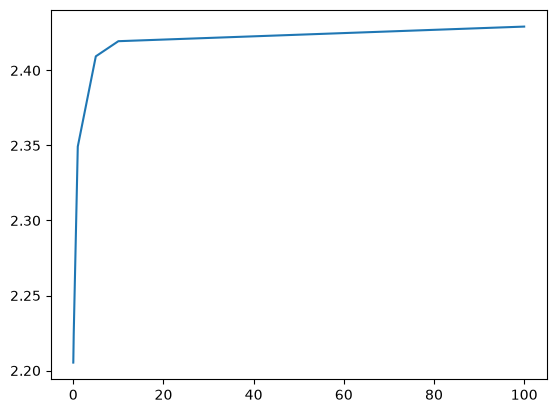

In [112]:
plt.plot(reg_list,score_list)

In [133]:
seed_list,score_list=  [],[]
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    df_train, df_val, df_test = split_data(df,seed=seed)
    mean_hp = df_train['horsepower'].mean()
    df_train_imp_0 = impute_col(df_train,col_name='horsepower',value=0)
    df_val_imp_0 = impute_col(df_val,col_name='horsepower',value=0)
    X_train,y_train = get_X_and_y(df_train_imp_0,x_cols=x_cols,y_col=y_col)
    X_val, y_val = get_X_and_y(df_val_imp_0,x_cols=x_cols,y_col=y_col)

    model = LinearModel(reg=0).fit(X_train, y_train)
    score = rmse(y_val, model.predict(X_val))
    seed_list.append(seed)
    score_list.append(score)
print(round(np.std(score_list),3))

0.029


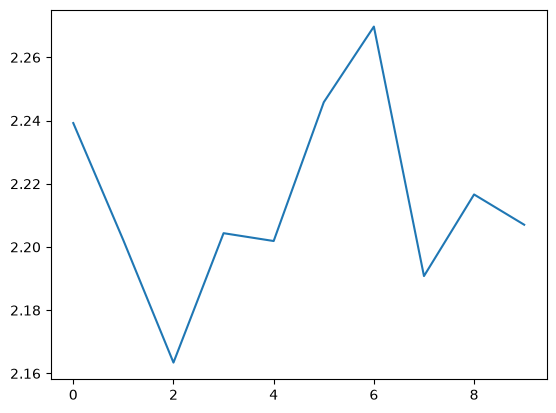

In [130]:
plt.plot(seed_list,score_list)

In [139]:
df_train, df_val, df_test = split_data(df,seed=9)
df_train = pd.concat([df_train,df_val])
mean_hp = df_train['horsepower'].mean()
df_train_imp_0 = impute_col(df_train,col_name='horsepower',value=0)
df_test_imp_0 = impute_col(df_test,col_name='horsepower',value=0)
X_train,y_train = get_X_and_y(df_train_imp_0,x_cols=x_cols,y_col=y_col)
X_test, y_test = get_X_and_y(df_test_imp_0,x_cols=x_cols,y_col=y_col)

model = LinearModel(reg=0.001).fit(X_train, y_train)
score = rmse(y_test, model.predict(X_test))
print(round(score,3))

2.236
